In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**PART-1 & 2**

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (8, 5)

# Adjust this path to match your Drive folder structure
file_path = '/content/drive/MyDrive/sydney_data.xlsx'

df = pd.read_excel(file_path, sheet_name='Data')
df = df[df['suburb'].notna()].copy()
df['sale_date'] = pd.to_datetime(df['sale_date'])

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (100, 15)


,suburb,postcode,address,sale_price,sale_date,property_type,bedrooms,bathrooms,car_spaces,building_size_sqm,year_built,school_catchment,listing_description,source_url,notes
0,Mosman,2088,305/55 Harbour Street,980000,2026-09-22,Apartment,1,1,1,75,2001,Mosman Public School,Nestled in one of Mosman's most convenient str...,https://www.domain.com.au/305-55-harbour-stree...,NaN
1,Mosman,2088,3/33 Mosman Street,871000,2026-09-18,Apartment,2,1,1,60,1967,Mosman High School,"Tucked away at the rear of the block, this cla...",https://www.domain.com.au/3-33-mosman-street-m...,NaN
2,Mosman,2088,"313/88 Vista Street, Mosman",905000,2026-09-17,Apartment,2,1,0,60,2004,Mosman Public School,"In the very heart of Mosman Village, this well...",https://www.domain.com.au/313-88-vista-street-...,NaN
3,Mosman,2088,8/88 Avenue Road,730000,2026-09-12,Apartment,1,1,1,40,1960,Mosman High School,"Embodying a light and airy ambiance, this char...",https://www.domain.com.au/8-88-avenue-road-mos...,NaN
4,Mosman,2088,7/10 Muston Street,750000,2026-09-08,Apartment,1,1,0,41,1966,Mosman High School,"Basking in a prime north aspect, this beautifu...",https://www.domain.com.au/7-10-muston-street-m...,NaN


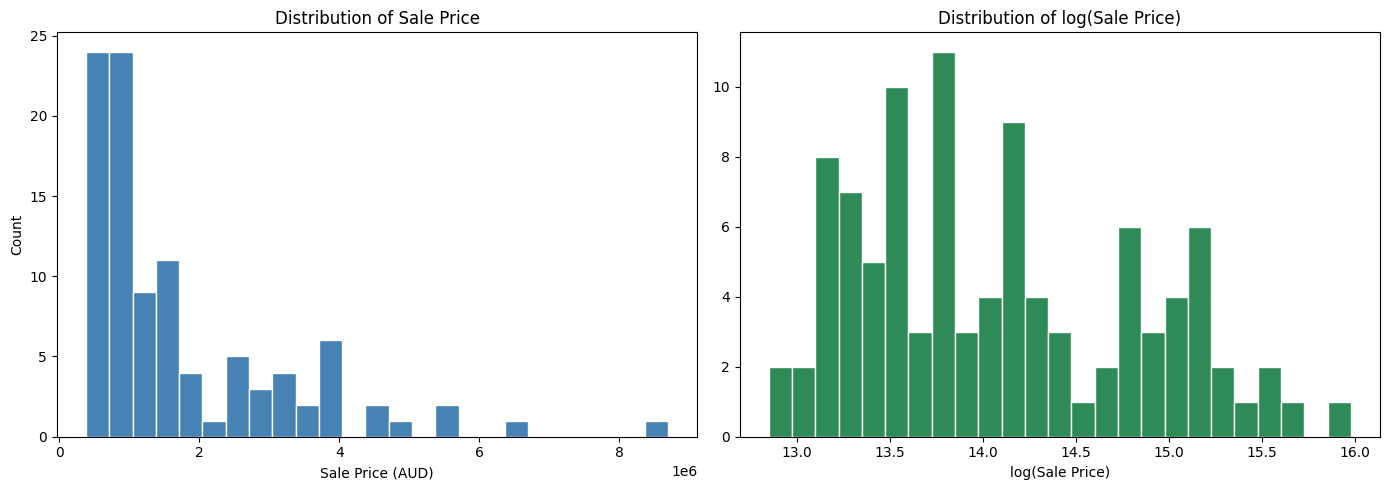

,sale_price
count,1.000000e+02
mean,1.751771e+06
std,1.516752e+06
min,3.800000e+05
25%,7.262500e+05
50%,1.155278e+06
75%,2.552000e+06
max,8.700000e+06


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df['sale_price'], bins=25, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Sale Price')
axes[0].set_xlabel('Sale Price (AUD)')
axes[0].set_ylabel('Count')

axes[1].hist(np.log1p(df['sale_price']), bins=25, color='seagreen', edgecolor='white')
axes[1].set_title('Distribution of log(Sale Price)')
axes[1].set_xlabel('log(Sale Price)')
plt.tight_layout()
plt.show()

df['sale_price'].describe()

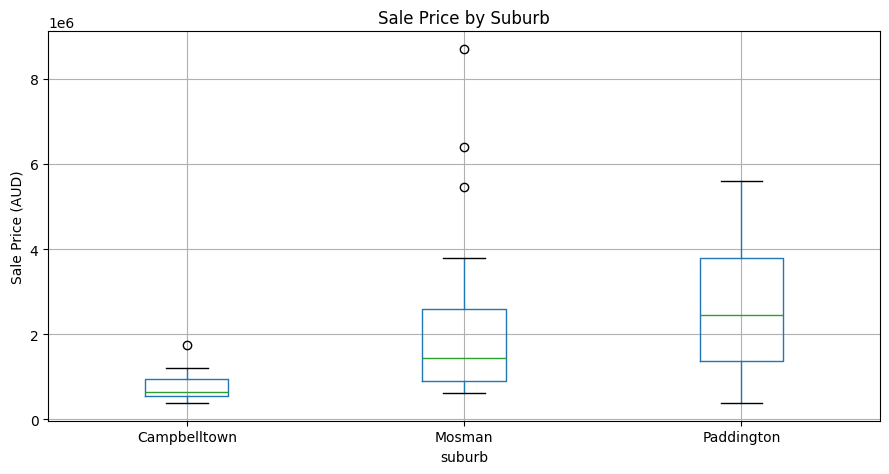

,count,median,mean,std,min,max
suburb,,,,,,
Campbelltown,35,650000.0,7.631744e+05,2.815444e+05,386500,1750000
Mosman,33,1440000.0,2.079091e+06,1.826582e+06,610000,8700000
Paddington,32,2450000.0,2.495500e+06,1.423887e+06,380000,5600000


In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
df.boxplot(column='sale_price', by='suburb', ax=ax)
plt.suptitle('')
ax.set_title('Sale Price by Suburb')
ax.set_ylabel('Sale Price (AUD)')
plt.tight_layout()
plt.show()

df.groupby('suburb')['sale_price'].agg(['count','median','mean','std','min','max'])

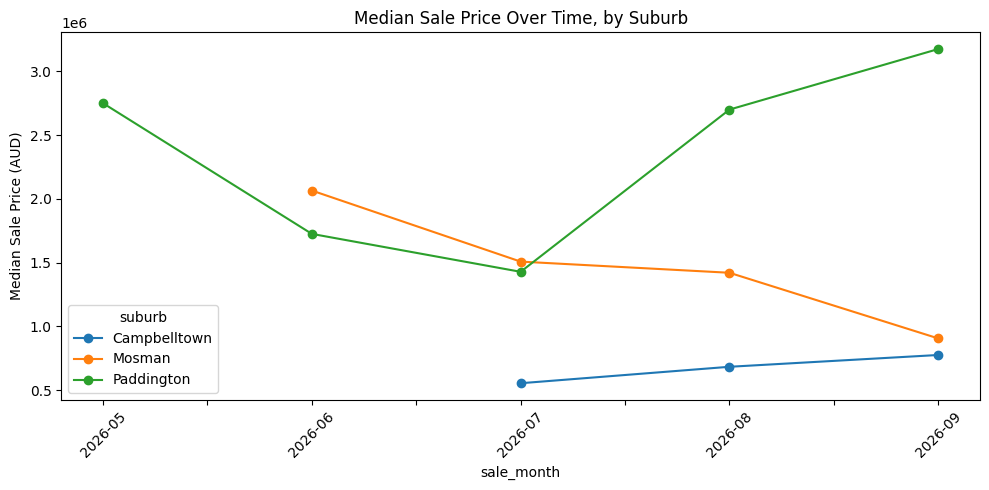

In [6]:
df_time = df.copy()
df_time['sale_month'] = df_time['sale_date'].dt.to_period('M').astype(str)
monthly = df_time.groupby(['sale_month','suburb'])['sale_price'].median().unstack()

fig, ax = plt.subplots(figsize=(10, 5))
monthly.plot(ax=ax, marker='o')
ax.set_title('Median Sale Price Over Time, by Suburb')
ax.set_ylabel('Median Sale Price (AUD)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [7]:
q1, q3 = df['sale_price'].quantile([0.25, 0.75])
iqr = q3 - q1
lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
outliers = df[(df['sale_price'] < lower) | (df['sale_price'] > upper)]

print(f"IQR bounds: [{lower:,.0f}, {upper:,.0f}]")
print(f"Number of price outliers: {len(outliers)}")
outliers[['suburb','address','sale_price','property_type','bedrooms','building_size_sqm']].sort_values('sale_price', ascending=False)

IQR bounds: [-2,012,375, 5,290,625]
Number of price outliers: 4


,suburb,address,sale_price,property_type,bedrooms,building_size_sqm
67,Mosman,5 Botanic Road,8700000,House,4,290
80,Mosman,5 Central Avenue,6399000,House,5,350
94,Paddington,76A Paddington Street,5600000,House,3,189
79,Mosman,17 Avenue Road,5450000,Apartment,5,255


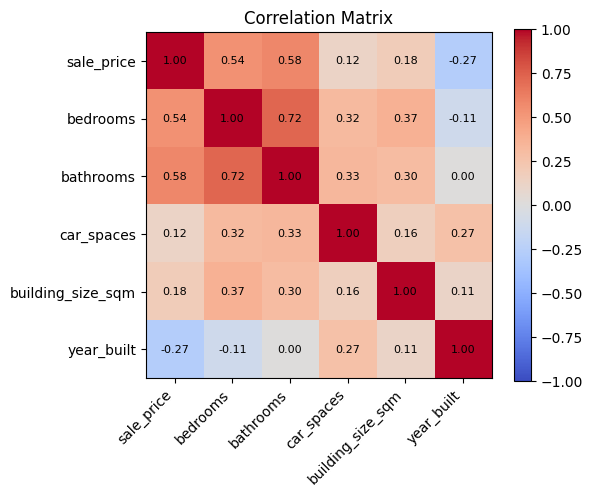

,sale_price
sale_price,1.000000
bathrooms,0.584704
bedrooms,0.537980
building_size_sqm,0.181194
car_spaces,0.119830
year_built,-0.273122


In [8]:
num_cols = ['sale_price','bedrooms','bathrooms','car_spaces','building_size_sqm','year_built']
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(6,5))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(num_cols))); ax.set_xticklabels(num_cols, rotation=45, ha='right')
ax.set_yticks(range(len(num_cols))); ax.set_yticklabels(num_cols)
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha='center', va='center', fontsize=8)
plt.colorbar(im)
ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.show()

corr['sale_price'].sort_values(ascending=False)

In [9]:
current_year = datetime.now().year
df_fe = df.copy()

df_fe['property_age'] = current_year - df_fe['year_built']
df_fe['price_per_sqm'] = df_fe['sale_price'] / df_fe['building_size_sqm']
df_fe['total_rooms'] = df_fe['bedrooms'] + df_fe['bathrooms']
df_fe['sale_year'] = df_fe['sale_date'].dt.year
df_fe['sale_month_num'] = df_fe['sale_date'].dt.month

df_fe[['suburb','sale_price','property_age','price_per_sqm','total_rooms']].head()

,suburb,sale_price,property_age,price_per_sqm,total_rooms
0,Mosman,980000,25,13066.666667,2
1,Mosman,871000,59,14516.666667,3
2,Mosman,905000,22,15083.333333,3
3,Mosman,730000,66,18250.000000,2
4,Mosman,750000,60,18292.682927,2


In [10]:
df_fe.groupby('suburb')['price_per_sqm'].median().sort_values(ascending=False)

,price_per_sqm
suburb,
Paddington,23755.299105
Mosman,16666.666667
Campbelltown,6333.333333


**PART-3**

In [11]:
from sklearn.model_selection import KFold, cross_validate, train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

features_num = ['bedrooms','bathrooms','car_spaces','building_size_sqm','property_age','total_rooms']
features_cat = ['suburb','property_type']

X = df_fe[features_num + features_cat]
y = df_fe['sale_price']

preprocess = ColumnTransformer([
    ('num', 'passthrough', features_num),
    ('cat', OneHotEncoder(handle_unknown='ignore'), features_cat)
])

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=300, max_depth=6, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42)
}

In [12]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, model in models.items():
    pipe = Pipeline([('prep', preprocess), ('model', model)])
    cv = cross_validate(pipe, X, y, cv=kf,
                         scoring=('neg_root_mean_squared_error','neg_mean_absolute_error','r2'),
                         return_train_score=True)
    results[name] = {
        'CV RMSE': -cv['test_neg_root_mean_squared_error'].mean(),
        'CV MAE': -cv['test_neg_mean_absolute_error'].mean(),
        'CV R2': cv['test_r2'].mean(),
        'Train R2 (avg)': cv['train_r2'].mean(),
    }

results_df = pd.DataFrame(results).T
results_df['R2 gap (train - CV)'] = results_df['Train R2 (avg)'] - results_df['CV R2']
results_df.round(3)

,CV RMSE,CV MAE,CV R2,Train R2 (avg),R2 gap (train - CV)
Linear Regression,901613.708,656894.447,0.520,0.773,0.253
Random Forest,673216.236,405761.491,0.743,0.955,0.213
Gradient Boosting,824284.973,481874.314,0.586,0.997,0.411


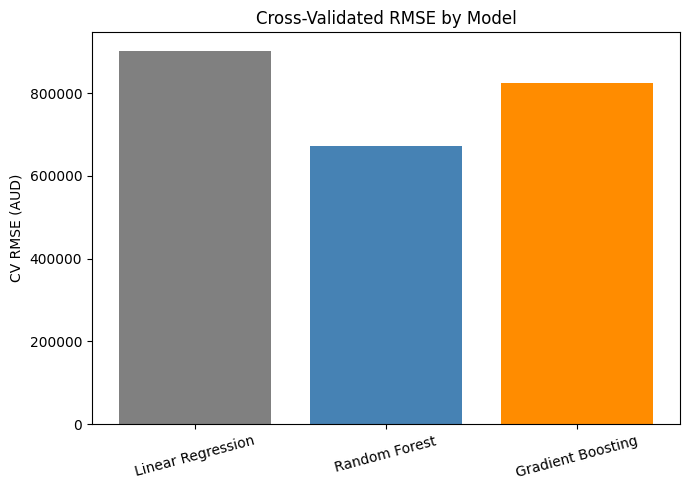

In [13]:
fig, ax = plt.subplots(figsize=(7,5))
ax.bar(results_df.index, results_df['CV RMSE'], color=['gray','steelblue','darkorange'])
ax.set_ylabel('CV RMSE (AUD)')
ax.set_title('Cross-Validated RMSE by Model')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [14]:
best_model_name = results_df['CV R2'].idxmax()  # you can override this manually based on your own judgement
print(f"Model with highest CV R2: {best_model_name}")

final_pipe = Pipeline([('prep', preprocess), ('model', models[best_model_name])])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
final_pipe.fit(X_train, y_train)
test_pred = final_pipe.predict(X_test)

print(f"Test RMSE: {mean_squared_error(y_test, test_pred) ** 0.5:,.0f}")
print(f"Test MAE:  {mean_absolute_error(y_test, test_pred):,.0f}")
print(f"Test R2:   {r2_score(y_test, test_pred):.3f}")

Model with highest CV R2: Random Forest
Test RMSE: 334,894
Test MAE:  238,394
Test R2:   0.953


**PART-4**

In [15]:
error_df = X_test.copy()
error_df['actual_price'] = y_test.values
error_df['predicted_price'] = test_pred
error_df['abs_error'] = (error_df['actual_price'] - error_df['predicted_price']).abs()
error_df['pct_error'] = error_df['abs_error'] / error_df['actual_price'] * 100

# bring back address and description for context
error_df = error_df.join(df_fe.loc[X_test.index, ['address','listing_description']])

top5_errors = error_df.sort_values('abs_error', ascending=False).head(5)
top5_errors[['address','suburb','property_type','bedrooms','bathrooms','building_size_sqm',
             'actual_price','predicted_price','abs_error','pct_error']]

,address,suburb,property_type,bedrooms,bathrooms,building_size_sqm,actual_price,predicted_price,abs_error,pct_error
22,28 Napier Street,Paddington,Terrace,4,2,177,4500000,3.690969e+06,809030.620028,17.978458
44,177A Spit Road,Mosman,House,3,2,245,3200000,3.903095e+06,703095.089263,21.971722
80,5 Central Avenue,Mosman,House,5,4,350,6399000,5.752286e+06,646713.833333,10.106483
70,10/16 Avenue Road,Mosman,Apartment,2,1,80,892000,1.389652e+06,497651.778446,55.790558
77,2/81A Glover Street,Mosman,Apartment,2,2,97,1440000,1.812474e+06,372474.496475,25.866284


**PART-5**

In [16]:
sample10 = error_df.sample(n=10, random_state=1).copy()
sample10 = sample10[['address','suburb','property_type','bedrooms','bathrooms','car_spaces',
                      'building_size_sqm','property_age','actual_price','predicted_price']]
sample10 = sample10.rename(columns={'predicted_price':'ml_prediction'})
sample10['llm_prediction'] = np.nan     # fill in manually after asking an LLM
sample10['human_prediction'] = np.nan   # fill in manually with your own estimate

sample10

,address,suburb,property_type,bedrooms,bathrooms,car_spaces,building_size_sqm,property_age,actual_price,ml_prediction,llm_prediction,human_prediction
45,5/32 Broughton St,Campbelltown,House,3,1,1,81,48,620000,7.711178e+05,NaN,NaN
76,2/60A Raglan Street,Mosman,Apartment,2,1,1,64,126,1175000,1.437275e+06,NaN,NaN
22,28 Napier Street,Paddington,Terrace,4,2,1,177,136,4500000,3.690969e+06,NaN,NaN
18,54 Stewart Street,Paddington,House,4,1,1,200,22,3965000,3.867945e+06,NaN,NaN
70,10/16 Avenue Road,Mosman,Apartment,2,1,0,80,61,892000,1.389652e+06,NaN,NaN
90,40/31-35 Chamberlain Street,Campbelltown,Apartment,2,2,2,126,15,515000,6.353433e+05,NaN,NaN
44,177A Spit Road,Mosman,House,3,2,2,245,33,3200000,3.903095e+06,NaN,NaN
77,2/81A Glover Street,Mosman,Apartment,2,2,1,97,28,1440000,1.812474e+06,NaN,NaN
80,5 Central Avenue,Mosman,House,5,4,2,350,106,6399000,5.752286e+06,NaN,NaN
53,4/2A Condamine Street,Campbelltown,Apartment,3,1,1,78,41,635000,7.299204e+05,NaN,NaN


In [23]:
sample10['llm_prediction'] = [650000, 1050000, 3600000, 3400000, 1200000, 580000, 3750000, 1700000, 5100000, 600000]
sample10['human_prediction'] = [650000, 1000000, 3500000, 3300000, 1150000, 600000, 3700000, 1650000, 5000000, 590000]

sample10

,address,suburb,property_type,bedrooms,bathrooms,car_spaces,building_size_sqm,property_age,actual_price,ml_prediction,llm_prediction,human_prediction
45,5/32 Broughton St,Campbelltown,House,3,1,1,81,48,620000,7.711178e+05,650000,650000
76,2/60A Raglan Street,Mosman,Apartment,2,1,1,64,126,1175000,1.437275e+06,1050000,1000000
22,28 Napier Street,Paddington,Terrace,4,2,1,177,136,4500000,3.690969e+06,3600000,3500000
18,54 Stewart Street,Paddington,House,4,1,1,200,22,3965000,3.867945e+06,3400000,3300000
70,10/16 Avenue Road,Mosman,Apartment,2,1,0,80,61,892000,1.389652e+06,1200000,1150000
90,40/31-35 Chamberlain Street,Campbelltown,Apartment,2,2,2,126,15,515000,6.353433e+05,580000,600000
44,177A Spit Road,Mosman,House,3,2,2,245,33,3200000,3.903095e+06,3750000,3700000
77,2/81A Glover Street,Mosman,Apartment,2,2,1,97,28,1440000,1.812474e+06,1700000,1650000
80,5 Central Avenue,Mosman,House,5,4,2,350,106,6399000,5.752286e+06,5100000,5000000
53,4/2A Condamine Street,Campbelltown,Apartment,3,1,1,78,41,635000,7.299204e+05,600000,590000


In [24]:
comp = sample10.copy()
for col in ['ml_prediction','llm_prediction','human_prediction']:
    comp[f'{col}_abs_error'] = (comp['actual_price'] - comp[col]).abs()
    comp[f'{col}_pct_error'] = comp[f'{col}_abs_error'] / comp['actual_price'] * 100

summary = comp[['ml_prediction_abs_error','llm_prediction_abs_error','human_prediction_abs_error']].mean()
summary.index = ['ML model (mean abs error)', 'LLM (mean abs error)', 'Human (mean abs error)']
print(summary)

comp[['address','suburb','actual_price','ml_prediction','llm_prediction','human_prediction']]

ML model (mean abs error)    375467.781677
LLM (mean abs error)         413700.000000
Human (mean abs error)       436700.000000
dtype: float64


,address,suburb,actual_price,ml_prediction,llm_prediction,human_prediction
45,5/32 Broughton St,Campbelltown,620000,7.711178e+05,650000,650000
76,2/60A Raglan Street,Mosman,1175000,1.437275e+06,1050000,1000000
22,28 Napier Street,Paddington,4500000,3.690969e+06,3600000,3500000
18,54 Stewart Street,Paddington,3965000,3.867945e+06,3400000,3300000
70,10/16 Avenue Road,Mosman,892000,1.389652e+06,1200000,1150000
90,40/31-35 Chamberlain Street,Campbelltown,515000,6.353433e+05,580000,600000
44,177A Spit Road,Mosman,3200000,3.903095e+06,3750000,3700000
77,2/81A Glover Street,Mosman,1440000,1.812474e+06,1700000,1650000
80,5 Central Avenue,Mosman,6399000,5.752286e+06,5100000,5000000
53,4/2A Condamine Street,Campbelltown,635000,7.299204e+05,600000,590000


**PART-6**

In [25]:
import joblib

# Refit Random Forest on the FULL dataset (not just train split) for deployment
final_pipe.fit(X, y)

joblib.dump(final_pipe, '/content/drive/MyDrive/sydney_housing_model.pkl')
joblib.dump({
    'features_num': features_num,
    'features_cat': features_cat,
    'suburbs': sorted(df_fe['suburb'].unique().tolist()),
    'property_types': sorted(df_fe['property_type'].unique().tolist())
}, '/content/drive/MyDrive/model_metadata.pkl')

print("Saved model and metadata to Google Drive")

Saved model and metadata to Google Drive
